<a href="https://colab.research.google.com/github/olcaykursun/ML/blob/main/Spring2026/transfer_learning_demo_using_texture_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

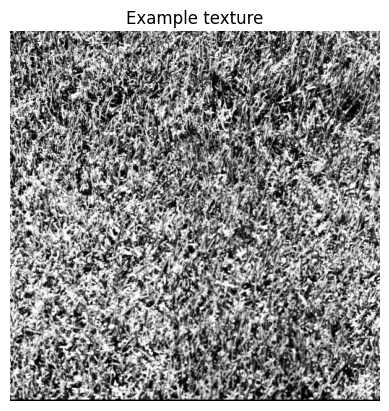

In [ ]:
url = "https://sipi.usc.edu/database/download.php?vol=textures&img=1.2.01"

img = Image.open(BytesIO(requests.get(url).content)).convert("L")

plt.imshow(img, cmap="gray")
plt.title("Example texture")
plt.axis("off")

In [ ]:
train_imgs = []
for i in range(1, 14):
    url = f"https://sipi.usc.edu/database/download.php?vol=textures&img=1.2.{i:02d}"
    img = Image.open(BytesIO(requests.get(url).content)).convert("L")
    train_imgs.append(img)

test_imgs = []
for i in range(1, 13):
    url = f"https://sipi.usc.edu/database/download.php?vol=textures&img=1.4.{i:02d}"
    img = Image.open(BytesIO(requests.get(url).content)).convert("L")
    test_imgs.append(img)

print("Train:", len(train_imgs), "Test:", len(test_imgs))

Train: 13 Test: 12


In [ ]:
def get_patches(img, n=20, size=64):
    arr = np.array(img)
    H, W = arr.shape
    patches = []

    for _ in range(n):
        i = np.random.randint(0, H - size)
        j = np.random.randint(0, W - size)
        patch = arr[i:i+size, j:j+size]
        patches.append(patch)

    return patches

In [ ]:
X = []
y = []

for label, img in enumerate(train_imgs):
    patches = get_patches(img, n=100)

    for p in patches:
        X.append(p)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(1300, 64, 64) (1300,)


In [ ]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((128,128)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor()
])

X_t = torch.stack([transform(x) for x in X])
y_t = torch.tensor(y)

print(X_t.shape)

torch.Size([1300, 3, 128, 128])


In [ ]:
vgg = models.vgg11(pretrained=True)

m = 1  # desired spatial size after adaptive pooling (m x m)

# Freeze early convolution layers (keep general edge/texture filters)
for p in vgg.features[:10].parameters():
    p.requires_grad = False

# Replace classifier:
# input size = 512 feature maps × (m x m spatial grid)
vgg.classifier = nn.Sequential(
    nn.Linear(512 * m * m, 128),
    nn.ReLU(),
    nn.Linear(128, 13)
)

# Force feature maps to size (m x m) before flattening
vgg.avgpool = nn.AdaptiveAvgPool2d((m, m))

vgg = vgg.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [ ]:
optimizer = torch.optim.Adam(vgg.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

X_t = X_t.to(device)
y_t = y_t.to(device)

for epoch in range(30):
    optimizer.zero_grad()

    outputs = vgg(X_t)
    loss = loss_fn(outputs, y_t)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 2.215531587600708
Epoch: 1 Loss: 1.8013237714767456
Epoch: 2 Loss: 2.5336127281188965
Epoch: 3 Loss: 1.837355375289917
Epoch: 4 Loss: 1.5097864866256714
Epoch: 5 Loss: 1.149948000907898
Epoch: 6 Loss: 0.9585562944412231
Epoch: 7 Loss: 0.705170214176178
Epoch: 8 Loss: 1.2204411029815674
Epoch: 9 Loss: 0.8589668869972229
Epoch: 10 Loss: 1.4134527444839478
Epoch: 11 Loss: 1.087005376815796
Epoch: 12 Loss: 0.4669803977012634
Epoch: 13 Loss: 1.2088576555252075
Epoch: 14 Loss: 0.534617006778717
Epoch: 15 Loss: 0.5206224918365479
Epoch: 16 Loss: 0.424206018447876
Epoch: 17 Loss: 0.29125675559043884
Epoch: 18 Loss: 0.2512373626232147
Epoch: 19 Loss: 0.22078871726989746
Epoch: 20 Loss: 0.1687873899936676
Epoch: 21 Loss: 0.09752161800861359
Epoch: 22 Loss: 0.050904758274555206
Epoch: 23 Loss: 0.02576925978064537
Epoch: 24 Loss: 0.02660643681883812
Epoch: 25 Loss: 0.021738233044743538
Epoch: 26 Loss: 0.014361836016178131
Epoch: 27 Loss: 0.006470903288573027
Epoch: 28 Loss: 0.005768

In [ ]:
# ==========================================
# Simple split (no sklearn)
# ==========================================

vgg = models.vgg11(pretrained=True)

m = 1  # desired spatial size after adaptive pooling (m x m)

# Freeze early convolution layers (keep general edge/texture filters)
for p in vgg.features[:10].parameters():
    p.requires_grad = False

# Replace classifier:
# input size = 512 feature maps × (m x m spatial grid)
vgg.classifier = nn.Sequential(
    nn.Linear(512 * m * m, 128),
    nn.ReLU(),
    nn.Linear(128, 13)
)

# Force feature maps to size (m x m) before flattening
vgg.avgpool = nn.AdaptiveAvgPool2d((m, m))

vgg = vgg.to(device)

n = X_t.shape[0]
idx = torch.randperm(n)

split = int(0.8 * n)

train_idx = idx[:split]
test_idx  = idx[split:]

X_train, y_train = X_t[train_idx], y_t[train_idx]
X_test,  y_test  = X_t[test_idx], y_t[test_idx]


# ==========================================
# Train on the training set
# ==========================================

optimizer = torch.optim.Adam(vgg.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

X_t = X_t.to(device)
y_t = y_t.to(device)

for epoch in range(30):
    optimizer.zero_grad()

    outputs = vgg(X_t)
    loss = loss_fn(outputs, y_t)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ==========================================
# Test accuracy
# ==========================================

vgg.eval()

with torch.no_grad():
    outputs = vgg(X_test)
    preds = outputs.argmax(dim=1)

acc = (preds == y_test).float().mean().item()
print("Test accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 0 Loss: 2.57517671585083
Epoch: 1 Loss: 2.3933706283569336
Epoch: 2 Loss: 1.9649699926376343
Epoch: 3 Loss: 1.6584622859954834
Epoch: 4 Loss: 1.3550456762313843
Epoch: 5 Loss: 1.386973261833191
Epoch: 6 Loss: 1.2471600770950317
Epoch: 7 Loss: 1.1925411224365234
Epoch: 8 Loss: 0.8080804944038391
Epoch: 9 Loss: 0.676701545715332
Epoch: 10 Loss: 0.3752889037132263
Epoch: 11 Loss: 0.2175634801387787
Epoch: 12 Loss: 0.5886712074279785
Epoch: 13 Loss: 0.9243488907814026
Epoch: 14 Loss: 1.0220495462417603
Epoch: 15 Loss: 0.384084016084671
Epoch: 16 Loss: 0.7163195013999939
Epoch: 17 Loss: 0.2709423303604126
Epoch: 18 Loss: 0.11695563793182373
Epoch: 19 Loss: 0.14235253632068634
Epoch: 20 Loss: 0.2060287743806839
Epoch: 21 Loss: 0.18856750428676605
Epoch: 22 Loss: 0.12209451198577881
Epoch: 23 Loss: 0.06419138610363007
Epoch: 24 Loss: 0.05379485338926315
Epoch: 25 Loss: 0.0585220567882061
Epoch: 26 Loss: 0.043172549456357956
Epoch: 27 Loss: 0.02864556573331356
Epoch: 28 Loss: 0.03127632

In [ ]:
feature_extractor = nn.Sequential(
    vgg.features,
    vgg.avgpool,
    nn.Flatten()
).to(device)

feature_extractor.eval()

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [ ]:
# ==========================================
# Extract patch-level features for the testset
# ==========================================

features = []
y_true = []

for label, img in enumerate(test_imgs):
    patches = get_patches(img, n=30)

    for p in patches:
        x = transform(p).unsqueeze(0).to(device)

        with torch.no_grad():
            f = feature_extractor(x).cpu().numpy().flatten()

        features.append(f)
        y_true.append(label)

features = np.array(features)
y_true = np.array(y_true)

print(features.shape, y_true.shape)

(360, 512) (360,)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=12, random_state=0)
y_pred = kmeans.fit_predict(features)
print("ARI:", adjusted_rand_score(y_true, y_pred))

ARI: 0.3792289468669745


In [ ]:
import pandas as pd

ct = pd.crosstab(y_true, y_pred)
print(ct)

col_0  0   1   2   3   4   5   6   7   8   9   10  11
row_0                                                
0      10   0   0   0   2   0   8   0   5   0   5   0
1       2   0   0  10   0   0   0   2  10   0   0   6
2       3   0   0  10   2   0   0   1   9   0   5   0
3       0   1   0   0  17   0   0  12   0   0   0   0
4       0   1   0   2   2   0   0  16   3   1   0   5
5       1  19   0   0   4   0   0   0   0   6   0   0
6      23   0   0   0   0   0   0   0   0   0   7   0
7       0  29   0   0   1   0   0   0   0   0   0   0
8       0   3   0   0   0  14   0   0   1  12   0   0
9       0   0  29   0   0   0   0   0   0   0   1   0
10      0   0  30   0   0   0   0   0   0   0   0   0
11      0   0  27   0   0   0   0   1   0   0   2   0


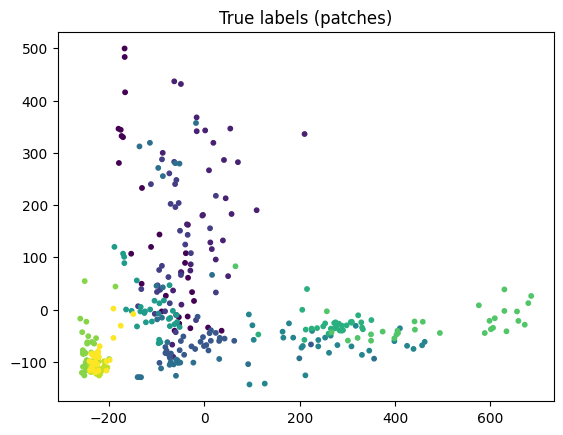

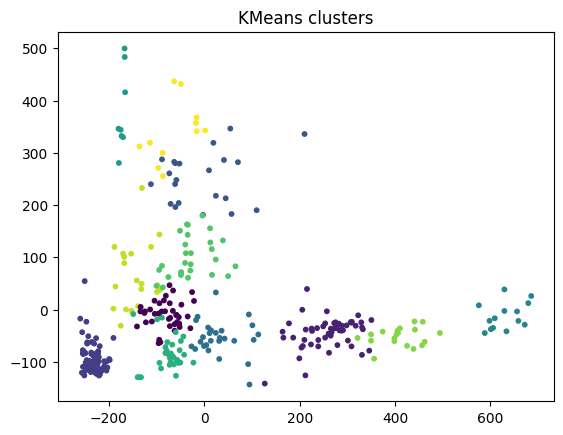

In [ ]:
from sklearn.decomposition import PCA

X2 = PCA(n_components=2).fit_transform(features)

plt.scatter(X2[:,0], X2[:,1], c=y_true, s=10)
plt.title("True labels (patches)")
plt.show()

plt.scatter(X2[:,0], X2[:,1], c=y_pred, s=10)
plt.title("KMeans clusters")
plt.show()

### Keeping Features General vs Fine-Tuning

In many cases, especially when the training data is limited, **keeping pretrained features general can lead to better transfer performance** than aggressive fine-tuning.

Deep networks such as VGG11 are trained on large-scale datasets and learn broadly useful visual patterns:

* early layers → edges, orientations
* mid layers → textures and repeated structures

When we fine-tune on a **small dataset** (e.g., a handful of texture images), the network may:

* overfit to specific training examples
* lose general-purpose features
* degrade performance on unseen data

For this reason, instead of fine-tuning, we will:

* **freeze the network (no training)**
* **extract features from earlier/mid layers**
* use those features for clustering unseen textures

> The goal is to preserve a **general feature space** that captures texture properties, rather than specializing to a small set of labeled examples.


In [ ]:
feature_extractor = nn.Sequential(
    vgg.features[:10],          # <-- cut here
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten()
).to(device)

feature_extractor.eval()

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
  )
  (1): AdaptiveAvgPool2d(output_size=(1, 1))
  (2): Flatten(start_dim=1, end_dim=-1)
)

In [ ]:
# ==========================================
# Extract patch-level features for the testset
# ==========================================

features = []
y_true = []

for label, img in enumerate(test_imgs):
    patches = get_patches(img, n=50)

    for p in patches:
        x = transform(p).unsqueeze(0).to(device)

        with torch.no_grad():
            f = feature_extractor(x).cpu().numpy().flatten()

        features.append(f)
        y_true.append(label)

features = np.array(features)
y_true = np.array(y_true)

print(features.shape, y_true.shape)

(600, 256) (600,)


In [ ]:
kmeans = KMeans(n_clusters=12, random_state=0)
y_pred = kmeans.fit_predict(features)

print("ARI:", adjusted_rand_score(y_true, y_pred))
ct = pd.crosstab(y_true, y_pred)
print(ct)

ARI: 0.5981410269755982
col_0  0   1   2   3   4   5   6   7   8   9   10  11
row_0                                                
0      13   0   0   0   0   0   0  12   0  16   0   9
1       0   0   0   7   0   0   0  18  24   1   0   0
2       0   0   0   2   0   0  45   2   0   1   0   0
3       0   0   0  50   0   0   0   0   0   0   0   0
4       0   2   0  24   0   0   0   6  16   0   2   0
5       0  36   0   3   1   0   0   2   0   1   7   0
6      26   0   0   3   0   0   0   1   0  20   0   0
7       0   0   0   0   0   0   0   1   0   0  49   0
8       0   0   0   0   0  49   0   1   0   0   0   0
9       0   0   0   0  49   0   0   1   0   0   0   0
10      0   0  48   0   0   0   0   2   0   0   0   0
11      0   0  45   0   0   0   0   5   0   0   0   0


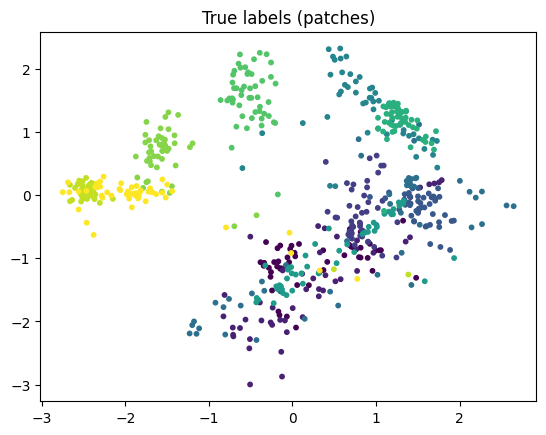

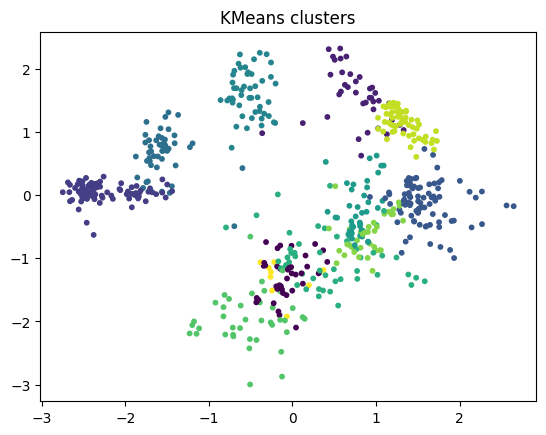

In [ ]:
from sklearn.decomposition import PCA

X2 = PCA(n_components=2).fit_transform(features)

plt.scatter(X2[:,0], X2[:,1], c=y_true, s=10)
plt.title("True labels (patches)")
plt.show()

plt.scatter(X2[:,0], X2[:,1], c=y_pred, s=10)
plt.title("KMeans clusters")
plt.show()